In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [125]:
assets = pd.read_excel('1 Project - Data.xlsx', sheet_name='Python FULL DATA', index_col=0, header=0)
factors = pd.read_excel('1 Project - Data.xlsx', sheet_name='Python FACTORS', index_col=0, header=[0, 2])

In [126]:
SHORTLISTED_FACTORS = [
    'US Muni', 'US Tbill 1-3yr', 'US AGG', 'Global AGG', 'US Dollar',
    'Commodities', 'Long Short HF', 'Event Driven HF', 'HF FOF Div',
    'Relative Value HF', 'EM Bond', 'TIPs', 'High Yield', 'MSCI World',
    'Gold', 'S&P500'
]

def factor_series(name):
    return pd.to_numeric(factors[(name, 'Factor')], errors='coerce').rename(name)

cash = factor_series('Cash')

xassets = pd.DataFrame({
    f'xasset_{asset_num}': pd.to_numeric(assets[f'Asset {asset_num}'], errors='coerce') - cash
    for asset_num in range(1, 6)
})

# factor_data holds the 16 shortlisted factors + HY-GAGG spread
factor_data = pd.concat([factor_series(name) for name in SHORTLISTED_FACTORS], axis=1)
factor_data['HY-GAGG'] = factor_data['High Yield'] - factor_data['Global AGG']

display(xassets.head())
display(factor_data.head())

,xasset_1,xasset_2,xasset_3,xasset_4,xasset_5
2004-01-30,0.005534,0.034039,0.031879,0.005729,0.011096
2004-02-27,0.007697,-0.033258,0.083235,0.019259,0.023028
2004-03-31,0.003592,-0.027465,-0.004376,0.010439,0.015725
2004-04-30,-0.018595,-0.047465,-0.086267,-0.029190,-0.044655
2004-05-31,-0.002978,0.048768,0.042917,-0.007740,0.014468


,US Muni,US Tbill 1-3yr,US AGG,Global AGG,US Dollar,Commodities,Long Short HF,Event Driven HF,HF FOF Div,Relative Value HF,EM Bond,TIPs,High Yield,MSCI World,Gold,S&P500,HY-GAGG
2004-01-30,0.004514,0.002107,0.008045,0.003733,-0.020593,0.018131,0.01950,0.02799,0.01538,0.01211,0.005127,0.012326,0.016153,0.016046,-0.031291,0.018355,0.012420
2004-02-27,0.014482,0.005026,0.010824,0.005152,0.005606,0.064882,0.01110,0.01202,0.01091,0.00550,0.003482,0.024775,-0.001097,0.016745,-0.015654,0.013899,-0.006249
2004-03-31,-0.004776,0.003215,0.007489,0.011077,0.018216,0.030877,0.00359,0.00058,0.00444,0.00433,0.024959,0.017390,0.006671,-0.006636,0.076486,-0.015086,-0.004405
2004-04-30,-0.020877,-0.010072,-0.026017,-0.036564,0.011407,-0.017737,-0.02078,-0.00562,-0.00709,-0.00506,-0.054311,-0.046496,-0.006601,-0.020481,-0.093094,-0.015698,0.029963
2004-05-31,-0.002264,-0.001130,-0.004006,0.004900,0.016968,0.016955,-0.00191,-0.00312,-0.00878,-0.00345,-0.014828,0.016444,-0.015712,0.009111,0.022754,0.013723,-0.020612


In [127]:
def single_factor_regression(y, x):
    clean = pd.concat([y.rename('y'), x.rename('x')], axis=1).dropna()
    model = OLS(clean['y'], add_constant(clean['x'], has_constant='add')).fit()
    return {
        'beta':    float(model.params.iloc[1]),
        'p_value': float(model.pvalues.iloc[1]),
        'r2':      float(model.rsquared),
        'n_obs':   int(model.nobs)
    }

def vif_table(X):
    return pd.Series(
        [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
        index=X.columns,
        name='VIF'
    )

In [128]:
# ── 135 single-factor regressions: 5 assets × 27 factors ─────────────────────
P_SIG   = 0.05   # significance threshold — used by all subsequent cells
_SF_FMT = {'Beta': '{:.6f}', 'P-value': '{:.4e}', 'R²': '{:.4f}'}

# Discover all factor names from the sheet (exclude Cash, preserve order)
_seen = set()
raw_factor_names = []
for col in factors.columns:
    name = col[0]
    if col[1] == 'Factor' and name != 'Cash' and name not in _seen:
        raw_factor_names.append(name)
        _seen.add(name)

# Build factor matrix: sheet factors + HY-GAGG (already in factor_data)
all_factor_data_full = pd.concat([factor_series(name) for name in raw_factor_names], axis=1)
all_factor_data_full['HY-GAGG'] = factor_data['HY-GAGG']
all_factor_names_full = raw_factor_names + ['HY-GAGG']

print(f"{len(xassets.columns)} assets × {len(all_factor_names_full)} factors "
      f"= {len(xassets.columns) * len(all_factor_names_full)} regressions")

records = []
for asset_col in xassets.columns:
    for factor_name in all_factor_names_full:
        res = single_factor_regression(xassets[asset_col], all_factor_data_full[factor_name])
        records.append({'Asset': asset_col, 'Factor': factor_name, 'Beta': res['beta'],
                        'P-value': res['p_value'], 'R²': res['r2'], 'N': res['n_obs']})

sf_df = pd.DataFrame(records)

def _hl_sig(row):
    c = 'background-color: #90EE90' if row['P-value'] <= P_SIG else ''
    return [c] * len(row)

styled_sf = sf_df.style.apply(_hl_sig, axis=1).format(_SF_FMT).set_caption(
    f'Single-Factor Regressions  —  green = p ≤ {P_SIG}'
)
display(styled_sf)

excel_out = 'single_factor_regressions.xlsx'
styled_sf.to_excel(excel_out, index=False, engine='openpyxl')
print(f"Saved → {excel_out}   ({int((sf_df['P-value'] <= P_SIG).sum())}/{len(sf_df)} highlighted)")

5 assets × 27 factors = 135 regressions


,Asset,Factor,Beta,P-value,R²,N
0,xasset_1,US Muni,0.414155,8.5967e-11,0.3012,120
1,xasset_1,US Tbill 1-3yr,1.118273,4.3658e-13,0.3601,120
2,xasset_1,US AGG,0.699651,1.8986e-41,0.7871,120
3,xasset_1,Global AGG,0.267759,1.6442e-12,0.3458,120
4,xasset_1,US Dollar,-0.041232,3.0814e-01,0.0088,120
5,xasset_1,Commodities,-0.006672,6.2354e-01,0.0020,120
6,xasset_1,Long Short HF,-0.044543,1.1176e-01,0.0213,120
7,xasset_1,Event Driven HF,-0.064668,7.9312e-02,0.0259,120
8,xasset_1,HF FOF Div,-0.088549,5.1985e-02,0.0316,120
9,xasset_1,Relative Value HF,-0.025337,6.0826e-01,0.0022,120


Saved → single_factor_regressions.xlsx   (96/135 highlighted)


In [129]:
# ── Full 27-factor OLS for each of the 5 assets ───────────────────────────────
from openpyxl.styles import PatternFill
green_fill = PatternFill(start_color='90EE90', end_color='90EE90', fill_type='solid')

overview_rows = []
detail = {}

for asset_col in xassets.columns:
    y = xassets[asset_col]
    clean = pd.concat([y, all_factor_data_full], axis=1).dropna()
    model = OLS(clean.iloc[:, 0], add_constant(clean.iloc[:, 1:], has_constant='add')).fit()
    sig_factors = [f for f, p in zip(all_factor_names_full, model.pvalues.iloc[1:]) if p <= P_SIG]
    overview_rows.append({
        'Asset': asset_col, 'N': int(model.nobs),
        'R²': round(model.rsquared, 4), 'Adj R²': round(model.rsquared_adj, 4),
        'F-stat': round(model.fvalue, 2), 'F p-value': model.f_pvalue,
        'Sig factors': len(sig_factors), 'Sig names': ', '.join(sig_factors),
    })
    detail[asset_col] = pd.DataFrame({
        'Factor':  all_factor_names_full,
        'Beta':    model.params.iloc[1:].values,
        'P-value': model.pvalues.iloc[1:].values,
        't-stat':  model.tvalues.iloc[1:].values,
    })

overview_df = pd.DataFrame(overview_rows)

def _hl_best(col):
    if col.name in ('R²', 'Adj R²', 'Sig factors'):
        top = col == col.max()
    elif col.name == 'F p-value':
        top = col == col.min()
    else:
        return [''] * len(col)
    return ['background-color: #FFD700' if v else '' for v in top]

print("=== Full 27-factor regression — overview (gold = best per column) ===")
display(overview_df.style.apply(_hl_best)
        .format({'R²': '{:.4f}', 'Adj R²': '{:.4f}', 'F-stat': '{:.2f}', 'F p-value': '{:.4e}'}))

for asset_col, df_res in detail.items():
    ov = overview_df.set_index('Asset').loc[asset_col]
    print(f"\n--- {asset_col}  |  R²={ov['R²']:.4f}  Adj R²={ov['Adj R²']:.4f}  "
          f"F={ov['F-stat']:.2f}  (p={ov['F p-value']:.2e}) ---")
    display(df_res.style.apply(_hl_sig, axis=1)
            .format({'Beta': '{:.6f}', 'P-value': '{:.4e}', 't-stat': '{:.3f}'}))

excel_out = 'full_27factor_regressions.xlsx'
with pd.ExcelWriter(excel_out, engine='openpyxl') as writer:
    overview_df.to_excel(writer, sheet_name='Overview', index=False)
    for asset_col, df_res in detail.items():
        df_res.to_excel(writer, sheet_name=asset_col, index=False)
        ws = writer.sheets[asset_col]
        p_col_idx = df_res.columns.get_loc('P-value') + 1
        for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
            p_val = row[p_col_idx - 1].value
            if p_val is not None and p_val <= P_SIG:
                for cell in row:
                    cell.fill = green_fill

print(f"\nSaved → {excel_out}")

=== Full 27-factor regression — overview (gold = best per column) ===


,Asset,N,R²,Adj R²,F-stat,F p-value,Sig factors,Sig names
0,xasset_1,120,0.8600,0.8209,21.98,3.3302e-29,3,"US AGG, Event Driven HF, HF FOF Div"
1,xasset_2,120,0.9327,0.9138,49.54,1.4438e-43,4,"MSCI World, MSCI Canada, US Value, S&P500"
2,xasset_3,120,0.6567,0.5607,6.84,1.9005e-12,3,"US AGG, Commodities, Event Driven HF"
3,xasset_4,120,0.7380,0.6648,10.08,2.5490e-17,5,"Global AGG, HF FOF Div, Relative Value HF, EM Bond, High Yield"
4,xasset_5,120,0.9746,0.9675,137.11,5.1713e-63,4,"US Muni, Global AGG, TIPs, High Yield"



--- xasset_1  |  R²=0.8600  Adj R²=0.8209  F=21.98  (p=3.33e-29) ---


,Factor,Beta,P-value,t-stat
0,US Muni,-0.022977,6.2152e-01,-0.495
1,US Tbill 1-3yr,-0.048891,7.1779e-01,-0.363
2,US AGG,0.715541,1.3006e-10,7.235
3,Global AGG,-0.028114,4.3890e-01,-0.777
4,US Dollar,0.006639,8.0582e-01,0.247
5,Commodities,-0.016608,1.6764e-01,-1.391
6,Long Short HF,0.143734,1.3273e-01,1.517
7,Event Driven HF,0.171441,3.7531e-02,2.110
8,HF FOF Div,-0.229097,7.6490e-03,-2.727
9,Relative Value HF,-0.072856,3.7672e-01,-0.888



--- xasset_2  |  R²=0.9327  Adj R²=0.9138  F=49.54  (p=1.44e-43) ---


...


--- xasset_4  |  R²=0.7380  Adj R²=0.6648  F=10.08  (p=2.55e-17) ---


,Factor,Beta,P-value,t-stat
0,US Muni,0.060985,5.9604e-01,0.532
1,US Tbill 1-3yr,0.118070,7.2399e-01,0.354
2,US AGG,-0.000931,9.9697e-01,-0.004
3,Global AGG,0.273973,2.8482e-03,3.065
4,US Dollar,0.044523,5.0521e-01,0.669
5,Commodities,0.017727,5.4960e-01,0.601
6,Long Short HF,0.168321,4.7418e-01,0.719
7,Event Driven HF,-0.349236,8.5322e-02,-1.739
8,HF FOF Div,1.225055,5.8736e-08,5.899
9,Relative Value HF,-0.742823,4.1275e-04,-3.664



--- xasset_5  |  R²=0.9746  Adj R²=0.9675  F=137.11  (p=5.17e-63) ---


,Factor,Beta,P-value,t-stat
0,US Muni,-0.132516,1.4456e-02,-2.492
1,US Tbill 1-3yr,-0.289343,6.4380e-02,-1.872
2,US AGG,-0.003997,9.7195e-01,-0.035
3,Global AGG,0.118658,5.1913e-03,2.863
4,US Dollar,-0.033834,2.7585e-01,-1.096
5,Commodities,0.007438,5.8815e-01,0.543
6,Long Short HF,-0.039393,7.1767e-01,-0.363
7,Event Driven HF,-0.158463,9.2163e-02,-1.702
8,HF FOF Div,0.043720,6.5091e-01,0.454
9,Relative Value HF,0.044873,6.3427e-01,0.477



Saved → full_27factor_regressions.xlsx


In [130]:
# ── VIF analysis: single-factor sig subset + full-model sig subset, per asset ──
from openpyxl.styles import PatternFill

VIF_WARN   = 5.0
VIF_SEVERE = 10.0
VIF_INF    = 9999   # sentinel replacing np.inf for Excel export

_C_RED    = 'FF4444'
_C_SEVERE = 'FF6B6B'
_C_WARN   = 'FFD700'
_FILL_RED    = PatternFill(start_color=_C_RED,    end_color=_C_RED,    fill_type='solid')
_FILL_SEVERE = PatternFill(start_color=_C_SEVERE, end_color=_C_SEVERE, fill_type='solid')
_FILL_WARN   = PatternFill(start_color=_C_WARN,   end_color=_C_WARN,   fill_type='solid')

def compute_vif(factor_matrix):
    clean = factor_matrix.dropna()
    return pd.Series(
        [variance_inflation_factor(clean.values, i) for i in range(clean.shape[1])],
        index=clean.columns, name='VIF'
    )

def flag_vif(v):
    if np.isinf(v):      return 'PERFECT (∞)'
    if v > VIF_SEVERE:   return 'SEVERE (>10)'
    if v > VIF_WARN:     return 'WARN (>5)'
    return 'OK'

def style_vif(row):
    v = row['VIF']
    if np.isinf(v):      c = f'background-color: #{_C_RED}'
    elif v > VIF_SEVERE: c = f'background-color: #{_C_SEVERE}'
    elif v > VIF_WARN:   c = f'background-color: #{_C_WARN}'
    else:                c = ''
    return [c] * len(row)

def make_vif_df(vif_series):
    df = vif_series.sort_values(ascending=False).reset_index()
    df.columns = ['Factor', 'VIF']
    df['Flag'] = df['VIF'].apply(flag_vif)
    return df

def write_vif_sheet(ws):
    for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
        try: v = float(row[1].value)
        except (TypeError, ValueError): continue
        if v >= VIF_INF:     fill = _FILL_RED
        elif v > VIF_SEVERE: fill = _FILL_SEVERE
        elif v > VIF_WARN:   fill = _FILL_WARN
        else:                fill = None
        if fill:
            for cell in row: cell.fill = fill

def _sig_factors(get_df):
    return {a: get_df(a).loc[lambda d: d['P-value'] <= P_SIG, 'Factor'].tolist()
            for a in xassets.columns}

def run_vif_block(label, sig_factor_dict):
    print("=" * 60)
    print(label)
    print("=" * 60)
    results = {}
    for asset_col in xassets.columns:
        sig_factors = sig_factor_dict[asset_col]
        if len(sig_factors) < 2:
            print(f"\n{asset_col}: only {len(sig_factors)} significant factor(s) — VIF not applicable")
            results[asset_col] = None
            continue
        vdf = make_vif_df(compute_vif(all_factor_data_full[sig_factors]))
        results[asset_col] = vdf
        print(f"\n{asset_col}  ({len(sig_factors)} sig factors):")
        display(vdf.style.apply(style_vif, axis=1)
                .format({'VIF': lambda v: '∞' if np.isinf(v) else f'{v:.2f}'}))
    return results

sf_vif_results   = run_vif_block(
    "PART 1 — VIF on single-factor-significant factors (p ≤ 0.05)",
    _sig_factors(lambda a: sf_df.loc[sf_df['Asset'] == a])
)
full_vif_results = run_vif_block(
    "\nPART 2 — VIF on full-model-significant factors (p ≤ 0.05)",
    _sig_factors(lambda a: detail[a])
)

excel_vif = 'vif_analysis.xlsx'
with pd.ExcelWriter(excel_vif, engine='openpyxl') as writer:
    for asset_col in xassets.columns:
        for suffix, res in [('_sf', sf_vif_results), ('_full', full_vif_results)]:
            vdf = res.get(asset_col)
            if vdf is None:
                continue
            sheet = f'{asset_col}{suffix}'
            export = vdf.copy()
            export['VIF'] = export['VIF'].replace([np.inf], VIF_INF)
            export.to_excel(writer, sheet_name=sheet, index=False)
            write_vif_sheet(writer.sheets[sheet])

print(f"\nSaved → {excel_vif}")

PART 1 — VIF on single-factor-significant factors (p ≤ 0.05)

xasset_1  (8 sig factors):


,Factor,VIF,Flag
0,US AGG,6.63,WARN (>5)
1,EM Bond,4.80,OK
2,Global AGG,3.65,OK
3,TIPs,3.20,OK
4,US Tbill 1-3yr,2.61,OK
5,HY-GAGG,2.61,OK
6,US Muni,2.13,OK
7,Gold,1.56,OK



xasset_2  (23 sig factors):


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Factor,VIF,Flag
0,HY-GAGG,∞,PERFECT (∞)
1,High Yield,∞,PERFECT (∞)
2,Global AGG,∞,PERFECT (∞)
3,S&P500,2391.35,SEVERE (>10)
4,MSCI World,2315.52,SEVERE (>10)
5,MSCI EAFE,1177.99,SEVERE (>10)
6,US Value,893.55,SEVERE (>10)
7,US Growth,806.34,SEVERE (>10)
8,MSCI Europe,267.94,SEVERE (>10)
9,US Mid Cap,94.88,SEVERE (>10)


...


xasset_4  (5 sig factors):


,Factor,VIF,Flag
0,Relative Value HF,9.40,WARN (>5)
1,High Yield,5.38,WARN (>5)
2,HF FOF Div,4.06,OK
3,EM Bond,3.68,OK
4,Global AGG,1.89,OK



xasset_5  (4 sig factors):


,Factor,VIF,Flag
0,TIPs,2.14,OK
1,Global AGG,1.98,OK
2,US Muni,1.54,OK
3,High Yield,1.20,OK



Saved → vif_analysis.xlsx


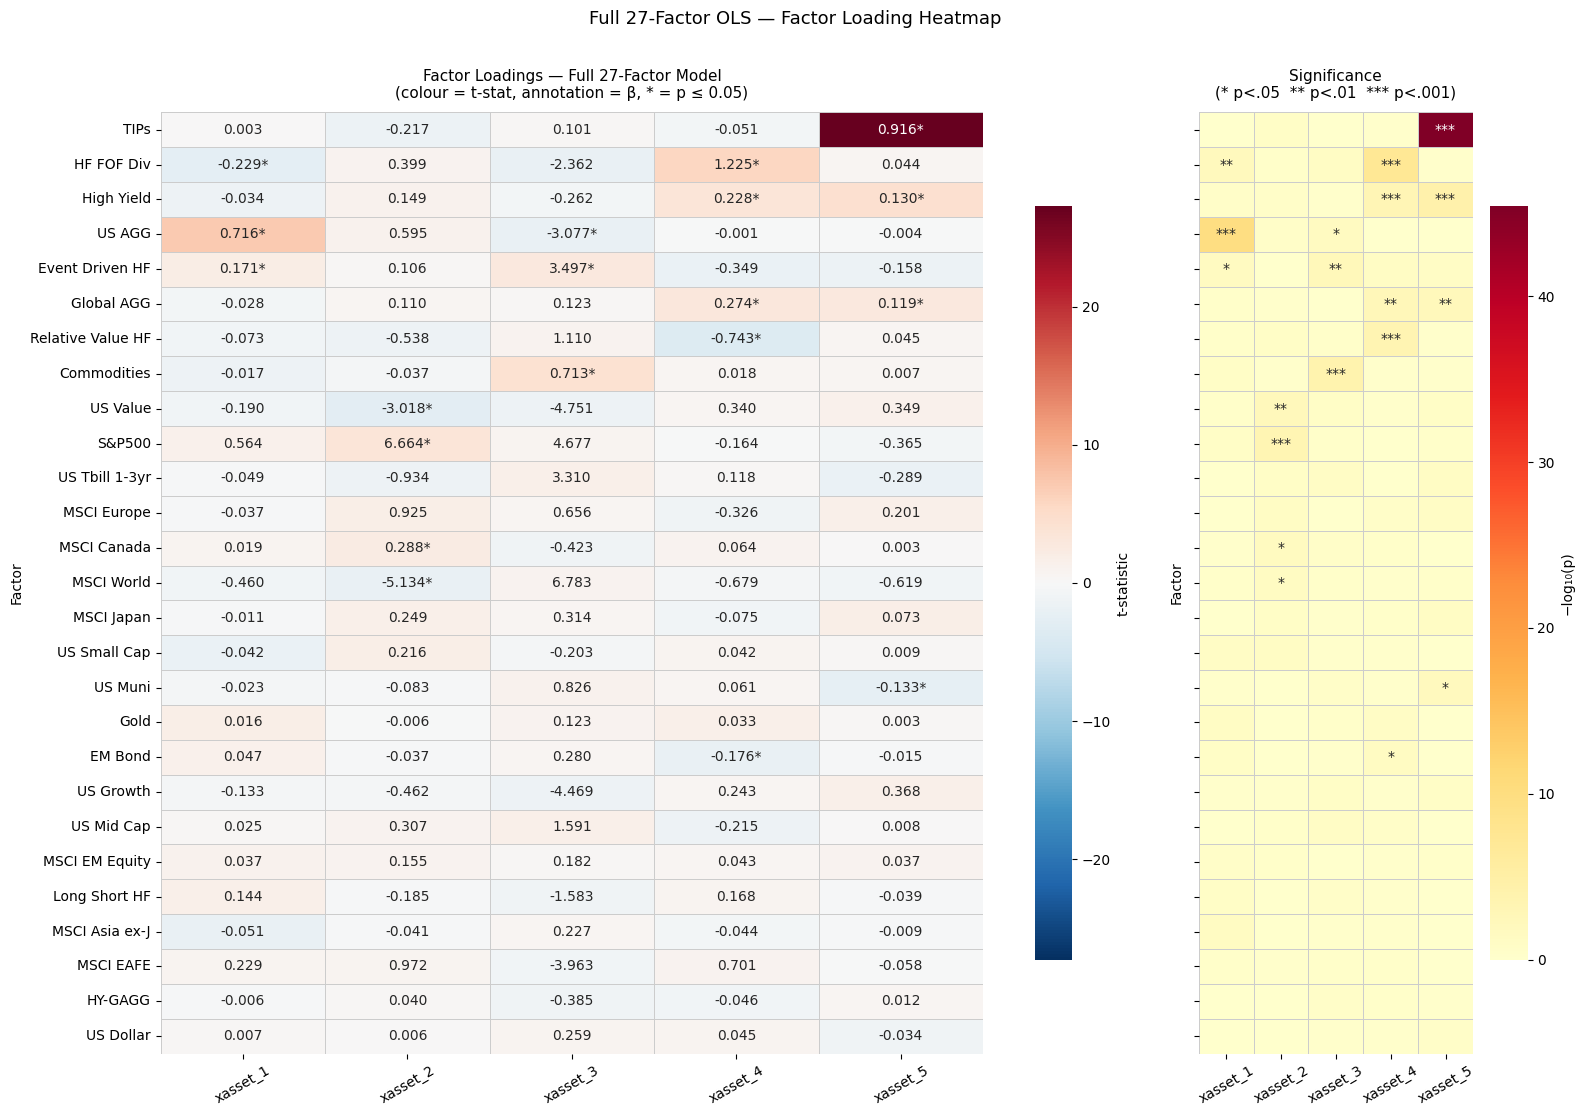

Saved → factor_heatmap.png


In [131]:
# ── Factor loading heatmap (full 27-factor model) ─────────────────────────────
import seaborn as sns

beta_mat  = pd.DataFrame({a: detail[a].set_index('Factor')['Beta']    for a in xassets.columns})
pval_mat  = pd.DataFrame({a: detail[a].set_index('Factor')['P-value'] for a in xassets.columns})
tstat_mat = pd.DataFrame({a: detail[a].set_index('Factor')['t-stat']  for a in xassets.columns})

factor_order = tstat_mat.abs().mean(axis=1).sort_values(ascending=False).index
beta_mat  = beta_mat.loc[factor_order]
pval_mat  = pval_mat.loc[factor_order]
tstat_mat = tstat_mat.loc[factor_order]

annot     = beta_mat.map(lambda b: f'{b:.3f}') + pval_mat.map(lambda p: '*' if p <= P_SIG else '')
sig_annot = pval_mat.map(lambda p: '***' if p <= 0.001 else ('**' if p <= 0.01 else ('*' if p <= 0.05 else '')))

fig, axes = plt.subplots(1, 2, figsize=(16, 11), gridspec_kw={'width_ratios': [3, 1]})

lim = max(abs(tstat_mat.values.min()), abs(tstat_mat.values.max()))
sns.heatmap(tstat_mat.astype(float), annot=annot, fmt='', cmap='RdBu_r', center=0,
            vmin=-lim, vmax=lim, linewidths=0.4, linecolor='#cccccc', ax=axes[0],
            cbar_kws={'label': 't-statistic', 'shrink': 0.8})
axes[0].set_title('Factor Loadings — Full 27-Factor Model\n(colour = t-stat, annotation = β, * = p ≤ 0.05)',
                  fontsize=11, pad=10)
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

log_p = -np.log10(pval_mat.astype(float).clip(lower=1e-300))
sns.heatmap(log_p.astype(float), annot=sig_annot, fmt='', cmap='YlOrRd', vmin=0,
            linewidths=0.4, linecolor='#cccccc', ax=axes[1],
            cbar_kws={'label': '−log₁₀(p)', 'shrink': 0.8})
axes[1].set_title('Significance\n(* p<.05  ** p<.01  *** p<.001)', fontsize=11, pad=10)
axes[1].set_yticklabels([])
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Full 27-Factor OLS — Factor Loading Heatmap', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('factor_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → factor_heatmap.png")

In [132]:
# ── Feature creation: spread factors from p-value comparison ──────────────────
# Logic mirrors HY-GAGG: find correlated factor pairs where both are significant
# in isolation but compete/degrade in the full joint model → their spread may
# capture a purer, more orthogonal signal.

CORR_THRESH = 0.70   # minimum |correlation| to consider a pair

# ── 1. P-value comparison table: single vs full model ─────────────────────────
pcomp_rows = []
for asset_col in xassets.columns:
    single_p = sf_df.loc[sf_df['Asset'] == asset_col].set_index('Factor')['P-value']
    full_p   = detail[asset_col].set_index('Factor')['P-value']
    for f in all_factor_names_full:
        sp, fp = single_p[f], full_p[f]
        if   sp <= P_SIG and fp <= P_SIG: status = 'Always sig'
        elif sp <= P_SIG and fp >  P_SIG: status = 'Lost sig ↓'
        elif sp >  P_SIG and fp <= P_SIG: status = 'Gained sig ↑'
        else:                              status = 'Always insig'
        pcomp_rows.append({'Asset': asset_col, 'Factor': f,
                            'P-single': sp, 'P-full': fp, 'Status': status})

pcomp_df = pd.DataFrame(pcomp_rows)

def _hl_status(row):
    c = {'Lost sig ↓':   'background-color: #FFD700',
         'Gained sig ↑': 'background-color: #90EE90',
         'Always sig':   'background-color: #d4edda'}.get(row['Status'], '')
    return [c] * len(row)

print("=== P-value comparison: single-factor vs full 27-factor model ===")
for asset_col in xassets.columns:
    sub = pcomp_df[pcomp_df['Asset'] == asset_col].drop(columns='Asset')
    changed = (sub['Status'].isin(['Lost sig ↓', 'Gained sig ↑'])).sum()
    print(f"\n{asset_col}  ({changed} factors changed significance):")
    display(sub.style.apply(_hl_status, axis=1)
            .format({'P-single': '{:.4e}', 'P-full': '{:.4e}'}))

# ── 2. Find spread candidates ──────────────────────────────────────────────────
# Criteria: |corr| > CORR_THRESH, both sig in ≥1 asset single-factor,
#           at least one loses significance in the full model for ≥1 asset.

factor_corr    = all_factor_data_full.corr()
sig_anywhere   = set(sf_df.loc[sf_df['P-value'] <= P_SIG, 'Factor'])
degraded_anywhere = set(pcomp_df.loc[pcomp_df['Status'] == 'Lost sig ↓', 'Factor'])

candidates = []
for i, fa in enumerate(all_factor_names_full):
    for fb in all_factor_names_full[i+1:]:
        corr = factor_corr.loc[fa, fb]
        if abs(corr) < CORR_THRESH:             continue
        if fa not in sig_anywhere:              continue
        if fb not in sig_anywhere:              continue
        if fa not in degraded_anywhere and fb not in degraded_anywhere: continue
        # spread direction: difference for positively correlated, sum for negative
        if corr > 0:
            series = all_factor_data_full[fa] - all_factor_data_full[fb]
            name   = f'{fa} − {fb}'
        else:
            series = all_factor_data_full[fa] + all_factor_data_full[fb]
            name   = f'{fa} + {fb}'
        candidates.append({'Name': name, 'A': fa, 'B': fb,
                            'Corr(A,B)': round(corr, 3), 'Series': series})

print(f"\n{'='*60}")
print(f"Spread candidates (|corr|>{CORR_THRESH}, both sig, ≥1 degrades): {len(candidates)}")
print('='*60)
for c in candidates:
    print(f"  {c['Name']}   corr={c['Corr(A,B)']:+.3f}")

# ── 3. Test all candidate spreads in single-factor regressions ─────────────────
spread_rows = []
for c in candidates:
    for asset_col in xassets.columns:
        res = single_factor_regression(xassets[asset_col], c['Series'].rename(c['Name']))
        spread_rows.append({'Feature': c['Name'], 'A': c['A'], 'B': c['B'],
                            'Corr(A,B)': c['Corr(A,B)'], 'Asset': asset_col,
                            'Beta': res['beta'], 'P-value': res['p_value'], 'R²': res['r2']})

spread_df = pd.DataFrame(spread_rows)

# ── 4. Display significant new features ────────────────────────────────────────
sig_spreads = spread_df[spread_df['P-value'] <= P_SIG].sort_values(['Asset', 'P-value'])
print(f"\nSignificant constructed features (p ≤ {P_SIG}): "
      f"{len(sig_spreads)}/{len(spread_df)}\n")

display(sig_spreads.style
        .apply(_hl_sig, axis=1)
        .format({'Beta': '{:.4f}', 'P-value': '{:.4e}',
                 'R²': '{:.4f}', 'Corr(A,B)': '{:.3f}'})
        .set_caption('Constructed spread features — green = p ≤ 0.05'))

# ── 5. Export ──────────────────────────────────────────────────────────────────
excel_feat = 'feature_creation.xlsx'
with pd.ExcelWriter(excel_feat, engine='openpyxl') as writer:
    pcomp_df.to_excel(writer, sheet_name='PValue_Comparison', index=False)
    spread_df.to_excel(writer, sheet_name='All_Spreads', index=False)
    sig_spreads.to_excel(writer, sheet_name='Significant_Spreads', index=False)
print(f"Saved → {excel_feat}")

=== P-value comparison: single-factor vs full 27-factor model ===

xasset_1  (9 factors changed significance):


,Factor,P-single,P-full,Status
0,US Muni,8.5967e-11,6.2152e-01,Lost sig ↓
1,US Tbill 1-3yr,4.3658e-13,7.1779e-01,Lost sig ↓
2,US AGG,1.8986e-41,1.3006e-10,Always sig
3,Global AGG,1.6442e-12,4.3890e-01,Lost sig ↓
4,US Dollar,3.0814e-01,8.0582e-01,Always insig
5,Commodities,6.2354e-01,1.6764e-01,Always insig
6,Long Short HF,1.1176e-01,1.3273e-01,Always insig
7,Event Driven HF,7.9312e-02,3.7531e-02,Gained sig ↑
8,HF FOF Div,5.1985e-02,7.6490e-03,Gained sig ↑
9,Relative Value HF,6.0826e-01,3.7672e-01,Always insig



xasset_2  (19 factors changed significance):


,Factor,P-single,P-full,Status
27,US Muni,7.3286e-01,7.1381e-01,Always insig
28,US Tbill 1-3yr,2.0248e-05,1.5850e-01,Lost sig ↓
29,US AGG,8.3309e-01,2.2009e-01,Always insig
30,Global AGG,2.6105e-02,5.3540e-01,Lost sig ↓
31,US Dollar,6.4710e-04,9.6171e-01,Lost sig ↓
32,Commodities,4.7853e-06,5.3074e-01,Lost sig ↓
33,Long Short HF,3.1515e-28,6.8896e-01,Lost sig ↓
34,Event Driven HF,3.2744e-23,7.8957e-01,Lost sig ↓
35,HF FOF Div,7.9956e-16,3.3185e-01,Lost sig ↓
36,Relative Value HF,1.2312e-15,1.8120e-01,Lost sig ↓



xasset_3  (22 factors changed significance):


...


xasset_5  (17 factors changed significance):


,Factor,P-single,P-full,Status
108,US Muni,6.5347e-09,1.4456e-02,Always sig
109,US Tbill 1-3yr,1.6942e-06,6.4380e-02,Lost sig ↓
110,US AGG,3.8340e-26,9.7195e-01,Lost sig ↓
111,Global AGG,1.1806e-17,5.1913e-03,Always sig
112,US Dollar,1.7894e-04,2.7585e-01,Lost sig ↓
113,Commodities,8.8116e-04,5.8815e-01,Lost sig ↓
114,Long Short HF,7.0877e-02,7.1767e-01,Always insig
115,Event Driven HF,1.1249e-01,9.2163e-02,Always insig
116,HF FOF Div,1.3412e-01,6.5091e-01,Always insig
117,Relative Value HF,1.1255e-03,6.3427e-01,Lost sig ↓



Spread candidates (|corr|>0.7, both sig, ≥1 degrades): 118
  US AGG − Global AGG   corr=+0.701
  US AGG − TIPs   corr=+0.805
  Commodities − MSCI Canada   corr=+0.719
  Long Short HF − Event Driven HF   corr=+0.934
  Long Short HF − HF FOF Div   corr=+0.892
  Long Short HF − Relative Value HF   corr=+0.856
  Long Short HF − High Yield   corr=+0.747
  Long Short HF − MSCI World   corr=+0.919
  Long Short HF − MSCI Canada   corr=+0.874
  Long Short HF − MSCI EAFE   corr=+0.898
  Long Short HF − MSCI EM Equity   corr=+0.886
  Long Short HF − MSCI Europe   corr=+0.870
  Long Short HF − MSCI Japan   corr=+0.722
  Long Short HF − MSCI Asia ex-J   corr=+0.865
  Long Short HF − US Growth   corr=+0.873
  Long Short HF − US Value   corr=+0.827
  Long Short HF − US Small Cap   corr=+0.827
  Long Short HF − US Mid Cap   corr=+0.894
  Long Short HF − S&P500   corr=+0.858
  Event Driven HF − HF FOF Div   corr=+0.890
  Event Driven HF − Relative Value HF   corr=+0.903
  Event Driven HF − High Yield 

,Feature,A,B,"Corr(A,B)",Asset,Beta,P-value,R²
310,High Yield − HY-GAGG,High Yield,HY-GAGG,0.810,xasset_1,0.2678,1.6442e-12,0.3458
260,EM Bond − High Yield,EM Bond,High Yield,0.739,xasset_1,0.2156,3.9721e-11,0.3101
5,US AGG − TIPs,US AGG,TIPs,0.805,xasset_1,-0.2448,1.4976e-07,0.2093
255,Relative Value HF − HY-GAGG,Relative Value HF,HY-GAGG,0.740,xasset_1,0.1330,1.1423e-04,0.1190
30,Long Short HF − High Yield,Long Short HF,High Yield,0.747,xasset_1,-0.1183,7.0019e-04,0.0931
105,Event Driven HF − High Yield,Event Driven HF,High Yield,0.773,xasset_1,-0.1110,1.9124e-03,0.0787
100,Event Driven HF − Relative Value HF,Event Driven HF,Relative Value HF,0.903,xasset_1,-0.2342,2.8365e-03,0.0730
165,HF FOF Div − Relative Value HF,HF FOF Div,Relative Value HF,0.851,xasset_1,-0.2668,3.0937e-03,0.0718
560,US Value − US Small Cap,US Value,US Small Cap,0.902,xasset_1,0.0716,1.5333e-02,0.0488
290,High Yield − US Growth,High Yield,US Growth,0.712,xasset_1,0.0579,1.6782e-02,0.0475


Saved → feature_creation.xlsx


Combined factor set: 27 original + 118 constructed = 145 total features

=== Combined OLS — overview (gold = best per column) ===


,Asset,N,R²,Adj R²,F-stat,F p-value,Sig factors,Sig names
0,xasset_1,120,0.8600,0.8209,21.98,3.3302e-29,26,"US AGG, Global AGG, Event Driven HF, HF FOF Div, TIPs, High Yield, HY-GAGG, US AGG − Global AGG, US AGG − TIPs, Long Short HF − HF FOF Div, Long Short HF − Relative Value HF, Event Driven HF − HF FOF Div, Event Driven HF − Relative Value HF, Event Driven HF − MSCI Asia ex-J, Event Driven HF − US Small Cap, HF FOF Div − MSCI Canada, HF FOF Div − MSCI EAFE, HF FOF Div − MSCI EM Equity, HF FOF Div − MSCI Europe, HF FOF Div − MSCI Asia ex-J, HF FOF Div − US Mid Cap, Relative Value HF − High Yield, Relative Value HF − MSCI EM Equity, Relative Value HF − HY-GAGG, High Yield − MSCI Asia ex-J, High Yield − HY-GAGG"
1,xasset_2,120,0.9327,0.9138,49.54,1.4438e-43,46,"Event Driven HF, High Yield, MSCI Canada, MSCI EM Equity, MSCI Europe, MSCI Asia ex-J, US Small Cap, US Mid Cap, S&P500, Long Short HF − US Value, Long Short HF − S&P500, Event Driven HF − MSCI World, Event Driven HF − US Value, Event Driven HF − S&P500, Relative Value HF − High Yield, Relative Value HF − MSCI Canada, Relative Value HF − MSCI EM Equity, Relative Value HF − MSCI Europe, Relative Value HF − US Mid Cap, High Yield − MSCI World, High Yield − US Value, High Yield − S&P500, MSCI World − MSCI Canada, MSCI World − MSCI EM Equity, MSCI World − MSCI Europe, MSCI World − MSCI Japan, MSCI World − US Small Cap, MSCI World − US Mid Cap, MSCI World − S&P500, MSCI Canada − US Value, MSCI Canada − S&P500, MSCI EAFE − US Value, MSCI EAFE − S&P500, MSCI EM Equity − US Value, MSCI EM Equity − S&P500, MSCI Europe − US Value, MSCI Europe − S&P500, MSCI Asia ex-J − US Value, MSCI Asia ex-J − S&P500, US Growth − US Value, US Growth − S&P500, US Value − US Small Cap, US Value − US Mid Cap, US Value − S&P500, US Small Cap − S&P500, US Mid Cap − S&P500"
2,xasset_3,120,0.6567,0.5607,6.84,1.9005e-12,18,"US AGG, Commodities, Event Driven HF, US Mid Cap, US AGG − Global AGG, Commodities − MSCI Canada, Long Short HF − Event Driven HF, Event Driven HF − HF FOF Div, Event Driven HF − High Yield, Event Driven HF − MSCI Canada, Event Driven HF − MSCI EM Equity, Event Driven HF − MSCI Asia ex-J, Event Driven HF − US Growth, Event Driven HF − US Value, Event Driven HF − US Small Cap, HF FOF Div − MSCI Asia ex-J, HF FOF Div − US Mid Cap, High Yield − US Mid Cap"
3,xasset_4,120,0.7380,0.6648,10.08,2.5490e-17,28,"Global AGG, HF FOF Div, Relative Value HF, High Yield, MSCI Canada, MSCI EM Equity, MSCI Asia ex-J, US Small Cap, HY-GAGG, Long Short HF − HF FOF Div, Long Short HF − Relative Value HF, Event Driven HF − HF FOF Div, HF FOF Div − Relative Value HF, HF FOF Div − MSCI Canada, HF FOF Div − MSCI EM Equity, HF FOF Div − MSCI Europe, HF FOF Div − MSCI Asia ex-J, HF FOF Div − US Growth, HF FOF Div − US Mid Cap, Relative Value HF − High Yield, Relative Value HF − MSCI Canada, Relative Value HF − MSCI EAFE, Relative Value HF − MSCI EM Equity, Relative Value HF − MSCI Asia ex-J, Relative Value HF − US Growth, Relative Value HF − US Mid Cap, EM Bond − High Yield, High Yield − HY-GAGG"
4,xasset_5,120,0.9746,0.9675,137.11,5.1713e-63,20,"US Muni, US AGG, Global AGG, TIPs, High Yield, MSCI Europe, HY-GAGG, US AGG − Global AGG, US AGG − TIPs, Long Short HF − High Yield, Event Driven HF − High Yield, Event Driven HF − MSCI EM Equity, Event Driven HF − MSCI Europe, Event Driven HF − US Growth, Relative Value HF − High Yield, Relative Value HF − HY-GAGG, High Yield − MSCI EM Equity, High Yield − MSCI Asia ex-J, High Yield − US Mid Cap, High Yield − HY-GAGG"



--- xasset_1  |  R²=0.8600  Adj R²=0.8209  F=21.98  (p=3.33e-29) ---  [green = orig sig, blue = spread sig]


,Factor,Beta,P-value,t-stat
0,US Muni,-0.022977,6.2152e-01,-0.495
1,US Tbill 1-3yr,-0.048891,7.1779e-01,-0.363
2,US AGG,0.311915,5.4678e-12,7.900
3,Global AGG,0.062881,2.8617e-07,5.535
4,US Dollar,0.006639,8.0582e-01,0.247
5,Commodities,-0.008354,1.5823e-01,-1.422
6,Long Short HF,0.007419,2.3663e-01,1.191
7,Event Driven HF,0.009751,4.5573e-02,2.027
8,HF FOF Div,-0.020638,5.7409e-03,-2.828
9,Relative Value HF,-0.010729,1.1488e-01,-1.592



--- xasset_2  |  R²=0.9327  Adj R²=0.9138  F=49.54  (p=1.44e-43) ---  [green = orig sig, blue = spread sig]


...

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Factor,VIF,Flag
0,Global AGG,∞,PERFECT (∞)
1,HF FOF Div − MSCI Canada,∞,PERFECT (∞)
2,Relative Value HF − US Mid Cap,∞,PERFECT (∞)
3,Relative Value HF − US Growth,∞,PERFECT (∞)
4,Relative Value HF − MSCI Asia ex-J,∞,PERFECT (∞)
5,Relative Value HF − MSCI EM Equity,∞,PERFECT (∞)
6,Relative Value HF − MSCI Canada,∞,PERFECT (∞)
7,Relative Value HF − High Yield,∞,PERFECT (∞)
8,HF FOF Div − US Mid Cap,∞,PERFECT (∞)
9,HF FOF Div − US Growth,∞,PERFECT (∞)



xasset_5  (20 sig factors):


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Factor,VIF,Flag
0,Event Driven HF − High Yield,∞,PERFECT (∞)
1,US AGG − TIPs,∞,PERFECT (∞)
2,High Yield − MSCI EM Equity,∞,PERFECT (∞)
3,Relative Value HF − HY-GAGG,∞,PERFECT (∞)
4,Relative Value HF − High Yield,∞,PERFECT (∞)
5,Event Driven HF − MSCI Europe,∞,PERFECT (∞)
6,Event Driven HF − MSCI EM Equity,∞,PERFECT (∞)
7,US AGG,∞,PERFECT (∞)
8,High Yield − HY-GAGG,∞,PERFECT (∞)
9,US AGG − Global AGG,∞,PERFECT (∞)


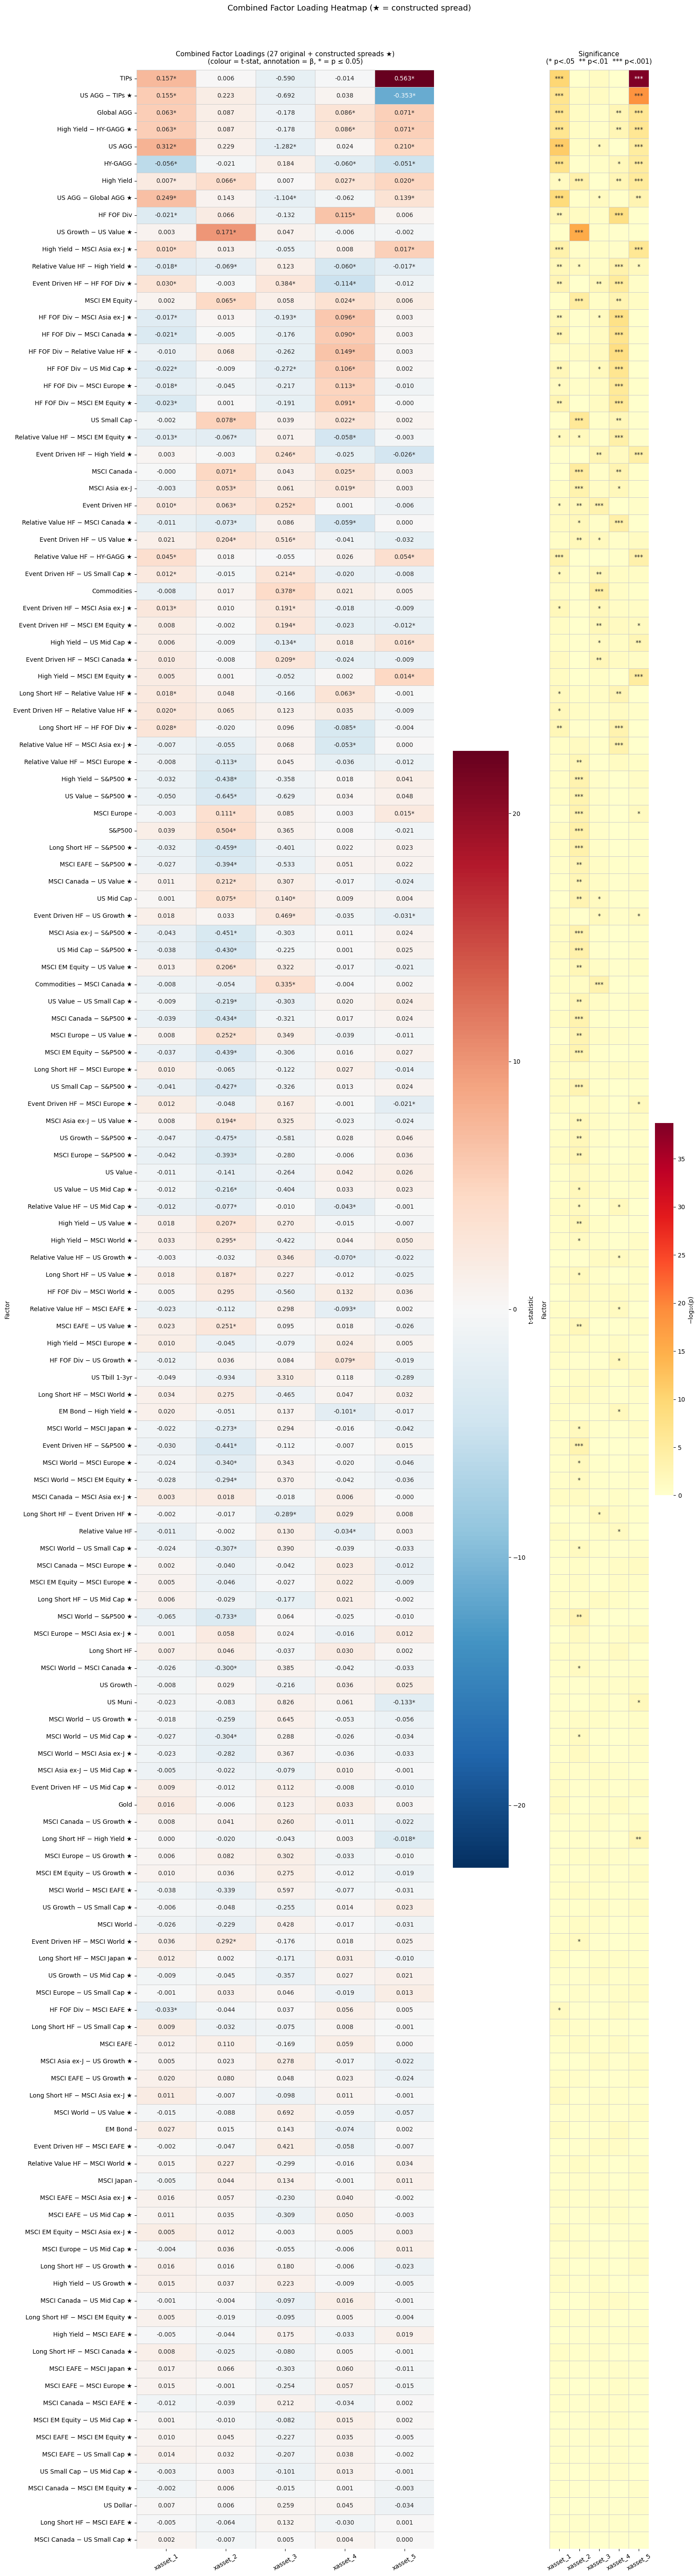

Saved → combined_heatmap.png
Saved → combined_factor_analysis.xlsx


In [133]:
# ── Combined pipeline: 27 original factors + constructed spreads ───────────────
# Mirrors how HY-GAGG was added alongside the original 27 — all features in one
# regression per asset, then VIF and heatmap on the full combined set.
import seaborn as sns

if not candidates:
    print("No spread candidates — lower CORR_THRESH or significance criteria.")
else:
    spread_names  = [c['Name'] for c in candidates]
    spread_matrix = pd.concat([c['Series'].rename(c['Name']) for c in candidates], axis=1)

    combined_matrix = pd.concat([all_factor_data_full, spread_matrix], axis=1)
    combined_names  = all_factor_names_full + spread_names

    print(f"Combined factor set: {len(all_factor_names_full)} original + "
          f"{len(spread_names)} constructed = {len(combined_names)} total features\n")

    # ── Full OLS per asset ─────────────────────────────────────────────────────
    comb_overview_rows = []
    comb_detail = {}

    for asset_col in xassets.columns:
        y     = xassets[asset_col]
        clean = pd.concat([y, combined_matrix], axis=1).dropna()
        model = OLS(clean.iloc[:, 0], add_constant(clean.iloc[:, 1:], has_constant='add')).fit()
        sig   = [f for f, p in zip(combined_names, model.pvalues.iloc[1:]) if p <= P_SIG]
        comb_overview_rows.append({
            'Asset': asset_col, 'N': int(model.nobs),
            'R²': round(model.rsquared, 4), 'Adj R²': round(model.rsquared_adj, 4),
            'F-stat': round(model.fvalue, 2), 'F p-value': model.f_pvalue,
            'Sig factors': len(sig), 'Sig names': ', '.join(sig),
        })
        comb_detail[asset_col] = pd.DataFrame({
            'Factor':  combined_names,
            'Beta':    model.params.iloc[1:].values,
            'P-value': model.pvalues.iloc[1:].values,
            't-stat':  model.tvalues.iloc[1:].values,
            'Is spread': [False] * len(all_factor_names_full) + [True] * len(spread_names),
        })

    comb_overview_df = pd.DataFrame(comb_overview_rows)

    def _hl_comb(row):
        if row['P-value'] > P_SIG:
            return [''] * len(row)
        c = 'background-color: #b3d9ff' if row['Is spread'] else 'background-color: #90EE90'
        return [c] * len(row)

    print("=== Combined OLS — overview (gold = best per column) ===")
    display(comb_overview_df.style.apply(_hl_best)
            .format({'R²': '{:.4f}', 'Adj R²': '{:.4f}',
                     'F-stat': '{:.2f}', 'F p-value': '{:.4e}'}))

    for asset_col, df_res in comb_detail.items():
        ov = comb_overview_df.set_index('Asset').loc[asset_col]
        print(f"\n--- {asset_col}  |  R²={ov['R²']:.4f}  Adj R²={ov['Adj R²']:.4f}  "
              f"F={ov['F-stat']:.2f}  (p={ov['F p-value']:.2e}) ---"
              f"  [green = orig sig, blue = spread sig]")
        # Apply style to full df (so _hl_comb can read 'Is spread'), then hide the column
        display(df_res.style
                .apply(_hl_comb, axis=1)
                .format({'Beta': '{:.6f}', 'P-value': '{:.4e}', 't-stat': '{:.3f}'})
                .hide(subset=['Is spread'], axis='columns'))

    # ── VIF on significant combined factors per asset ──────────────────────────
    print("\n" + "=" * 60)
    print("VIF on significant combined factors (p ≤ 0.05), per asset")
    print("=" * 60)
    comb_vif_results = {}
    for asset_col in xassets.columns:
        sig_feats = comb_detail[asset_col].loc[
            comb_detail[asset_col]['P-value'] <= P_SIG, 'Factor'].tolist()
        if len(sig_feats) < 2:
            print(f"\n{asset_col}: {len(sig_feats)} significant factor(s) — VIF not applicable")
            comb_vif_results[asset_col] = None
            continue
        vdf = make_vif_df(compute_vif(combined_matrix[sig_feats]))
        comb_vif_results[asset_col] = vdf
        print(f"\n{asset_col}  ({len(sig_feats)} sig factors):")
        display(vdf.style.apply(style_vif, axis=1)
                .format({'VIF': lambda v: '∞' if np.isinf(v) else f'{v:.2f}'}))

    # ── Heatmap ────────────────────────────────────────────────────────────────
    c_beta  = pd.DataFrame({a: comb_detail[a].set_index('Factor')['Beta']    for a in xassets.columns})
    c_pval  = pd.DataFrame({a: comb_detail[a].set_index('Factor')['P-value'] for a in xassets.columns})
    c_tstat = pd.DataFrame({a: comb_detail[a].set_index('Factor')['t-stat']  for a in xassets.columns})

    feat_order = c_tstat.abs().mean(axis=1).sort_values(ascending=False).index
    c_beta  = c_beta.loc[feat_order]
    c_pval  = c_pval.loc[feat_order]
    c_tstat = c_tstat.loc[feat_order]

    # y-axis labels: append ★ to mark constructed spreads
    spread_set  = set(spread_names)
    ylabels     = [f'{f} ★' if f in spread_set else f for f in feat_order]

    c_annot     = c_beta.map(lambda b: f'{b:.3f}') + c_pval.map(lambda p: '*' if p <= P_SIG else '')
    c_sig_annot = c_pval.map(lambda p: '***' if p <= 0.001 else ('**' if p <= 0.01 else ('*' if p <= 0.05 else '')))

    fig_h = max(8, len(feat_order) * 0.4)
    fig, axes = plt.subplots(1, 2, figsize=(16, fig_h), gridspec_kw={'width_ratios': [3, 1]})

    lim = max(abs(c_tstat.values.min()), abs(c_tstat.values.max()))
    sns.heatmap(c_tstat.astype(float), annot=c_annot, fmt='', cmap='RdBu_r', center=0,
                vmin=-lim, vmax=lim, linewidths=0.4, linecolor='#cccccc', ax=axes[0],
                yticklabels=ylabels, cbar_kws={'label': 't-statistic', 'shrink': 0.8})
    axes[0].set_title('Combined Factor Loadings (27 original + constructed spreads ★)\n'
                      '(colour = t-stat, annotation = β, * = p ≤ 0.05)', fontsize=11, pad=10)
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].tick_params(axis='y', rotation=0)

    log_p = -np.log10(c_pval.astype(float).clip(lower=1e-300))
    sns.heatmap(log_p.astype(float), annot=c_sig_annot, fmt='', cmap='YlOrRd', vmin=0,
                linewidths=0.4, linecolor='#cccccc', ax=axes[1],
                yticklabels=[], cbar_kws={'label': '−log₁₀(p)', 'shrink': 0.8})
    axes[1].set_title('Significance\n(* p<.05  ** p<.01  *** p<.001)', fontsize=11, pad=10)
    axes[1].tick_params(axis='x', rotation=30)

    plt.suptitle('Combined Factor Loading Heatmap (★ = constructed spread)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('combined_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → combined_heatmap.png")

    # ── Excel export ───────────────────────────────────────────────────────────
    blue_fill  = PatternFill(start_color='b3d9ff', end_color='b3d9ff', fill_type='solid')
    excel_comb = 'combined_factor_analysis.xlsx'
    with pd.ExcelWriter(excel_comb, engine='openpyxl') as writer:
        comb_overview_df.to_excel(writer, sheet_name='Overview', index=False)
        for asset_col, df_res in comb_detail.items():
            out = df_res.drop(columns='Is spread')
            out.to_excel(writer, sheet_name=asset_col, index=False)
            ws = writer.sheets[asset_col]
            p_col = out.columns.get_loc('P-value') + 1
            is_spread_col = df_res['Is spread'].values
            for i, row in enumerate(ws.iter_rows(min_row=2, max_row=ws.max_row)):
                p_val = row[p_col - 1].value
                if p_val is not None and p_val <= P_SIG:
                    fill = green_fill if not is_spread_col[i] else blue_fill
                    for cell in row: cell.fill = fill
        for asset_col, vdf in comb_vif_results.items():
            if vdf is None: continue
            export = vdf.copy()
            export['VIF'] = export['VIF'].replace([np.inf], VIF_INF)
            export.to_excel(writer, sheet_name=f'{asset_col}_vif', index=False)
            write_vif_sheet(writer.sheets[f'{asset_col}_vif'])
    print(f"Saved → {excel_comb}")